# Descrição das características


In [2]:
%%html
<link rel="stylesheet" href="./style.css">

In [3]:
from typing import Literal

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import HTML, display

from columns import get_name_of_column
from data import dd_df
from plotting import plot_bar_graph, plot_histogram

'Data types:'

age                    int64
systolic_bp            int64
diastolic_bp           int64
blood_sugar          float64
body_temperature     float64
heart_rate             int64
risk_level          category
dtype: object

'\nMissing values:'

age                 0
systolic_bp         0
diastolic_bp        0
blood_sugar         0
body_temperature    0
heart_rate          0
risk_level          0
dtype: int64

'\nDuplicated rows:'

np.int64(9)

In [4]:
def get_numerical_range(
    series: pd.Series,
):
    min_value, max_value = series.min(), series.max()
    if hasattr(min_value, "strftime") and hasattr(max_value, "strftime"):
        min_text = min_value.strftime("%Y-%m-%d")
        max_text = max_value.strftime("%Y-%m-%d")
    else:
        min_text = str(min_value)
        max_text = str(max_value)
    return f"[{min_text}, {max_text}]"

In [5]:
def display_column_description(
    series: pd.Series,
    type_name: str,
    feature_type: Literal["categorical", "numerical", "other"] = "other",
):
    column_name = series.name

    if not isinstance(column_name, str):
        raise TypeError("The series must have a string column name.")

    descriptive_name = get_name_of_column(column_name)
    block_to_display = f"<table><caption>{descriptive_name}</caption><tbody>"

    block_to_display += f"""
    <tr><th>ID</th><td colspan="2">{series.name}</td></tr>
    <tr><th>Tipo</th><td colspan="2">{type_name}</td></tr>"""

    if feature_type == "categorical":
        values = sorted(series.dropna().unique().tolist())
        values_html = (
            "<ul style='list-style-type: none;'>"
            + "".join(f"<li>{v}</li>" for v in values)
            + "</ul>"
        )
        block_to_display += f"<tr><th>Valores</th><td>{values_html}</td></tr>"

    elif feature_type == "numerical":
        block_to_display += f"""<tr><th>Intervalo</th><td colspan="2">{get_numerical_range(series)}</td></tr>"""
        block_to_display += f"""
        <tr><th>Média</th><td colspan="2">{series.mean():.2f}</td></tr>
        <tr><th>Mediana</th><td colspan="2">{series.median():.2f}</td></tr>
        <tr><th>Desvio padrão</th><td colspan="2">{series.std():.2f}</td></tr>
        <tr><th rowspan="5">Percentil</th><th>05%</th><td>{series.quantile(0.05):.2f}</td></tr>
        <tr><th>25%</th><td>{series.quantile(0.25):.2f}</td></tr>
        <tr><th>50%</th><td>{series.quantile(0.5):.2f}</td></tr>
        <tr><th>75%</th><td>{series.quantile(0.75):.2f}</td></tr>
        <tr><th>95%</th><td>{series.quantile(0.95):.2f}</td></tr>"""
        plt.boxplot(series.dropna())
        plt.xlabel("Boxplot")
        plt.ylabel(descriptive_name)

    display(HTML(block_to_display + "</tbody></table>"))
    plt.show()


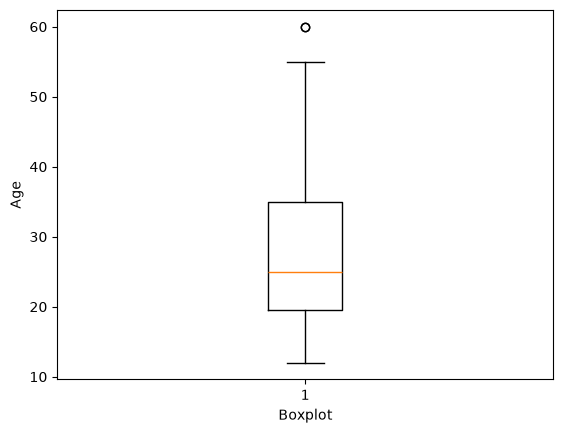

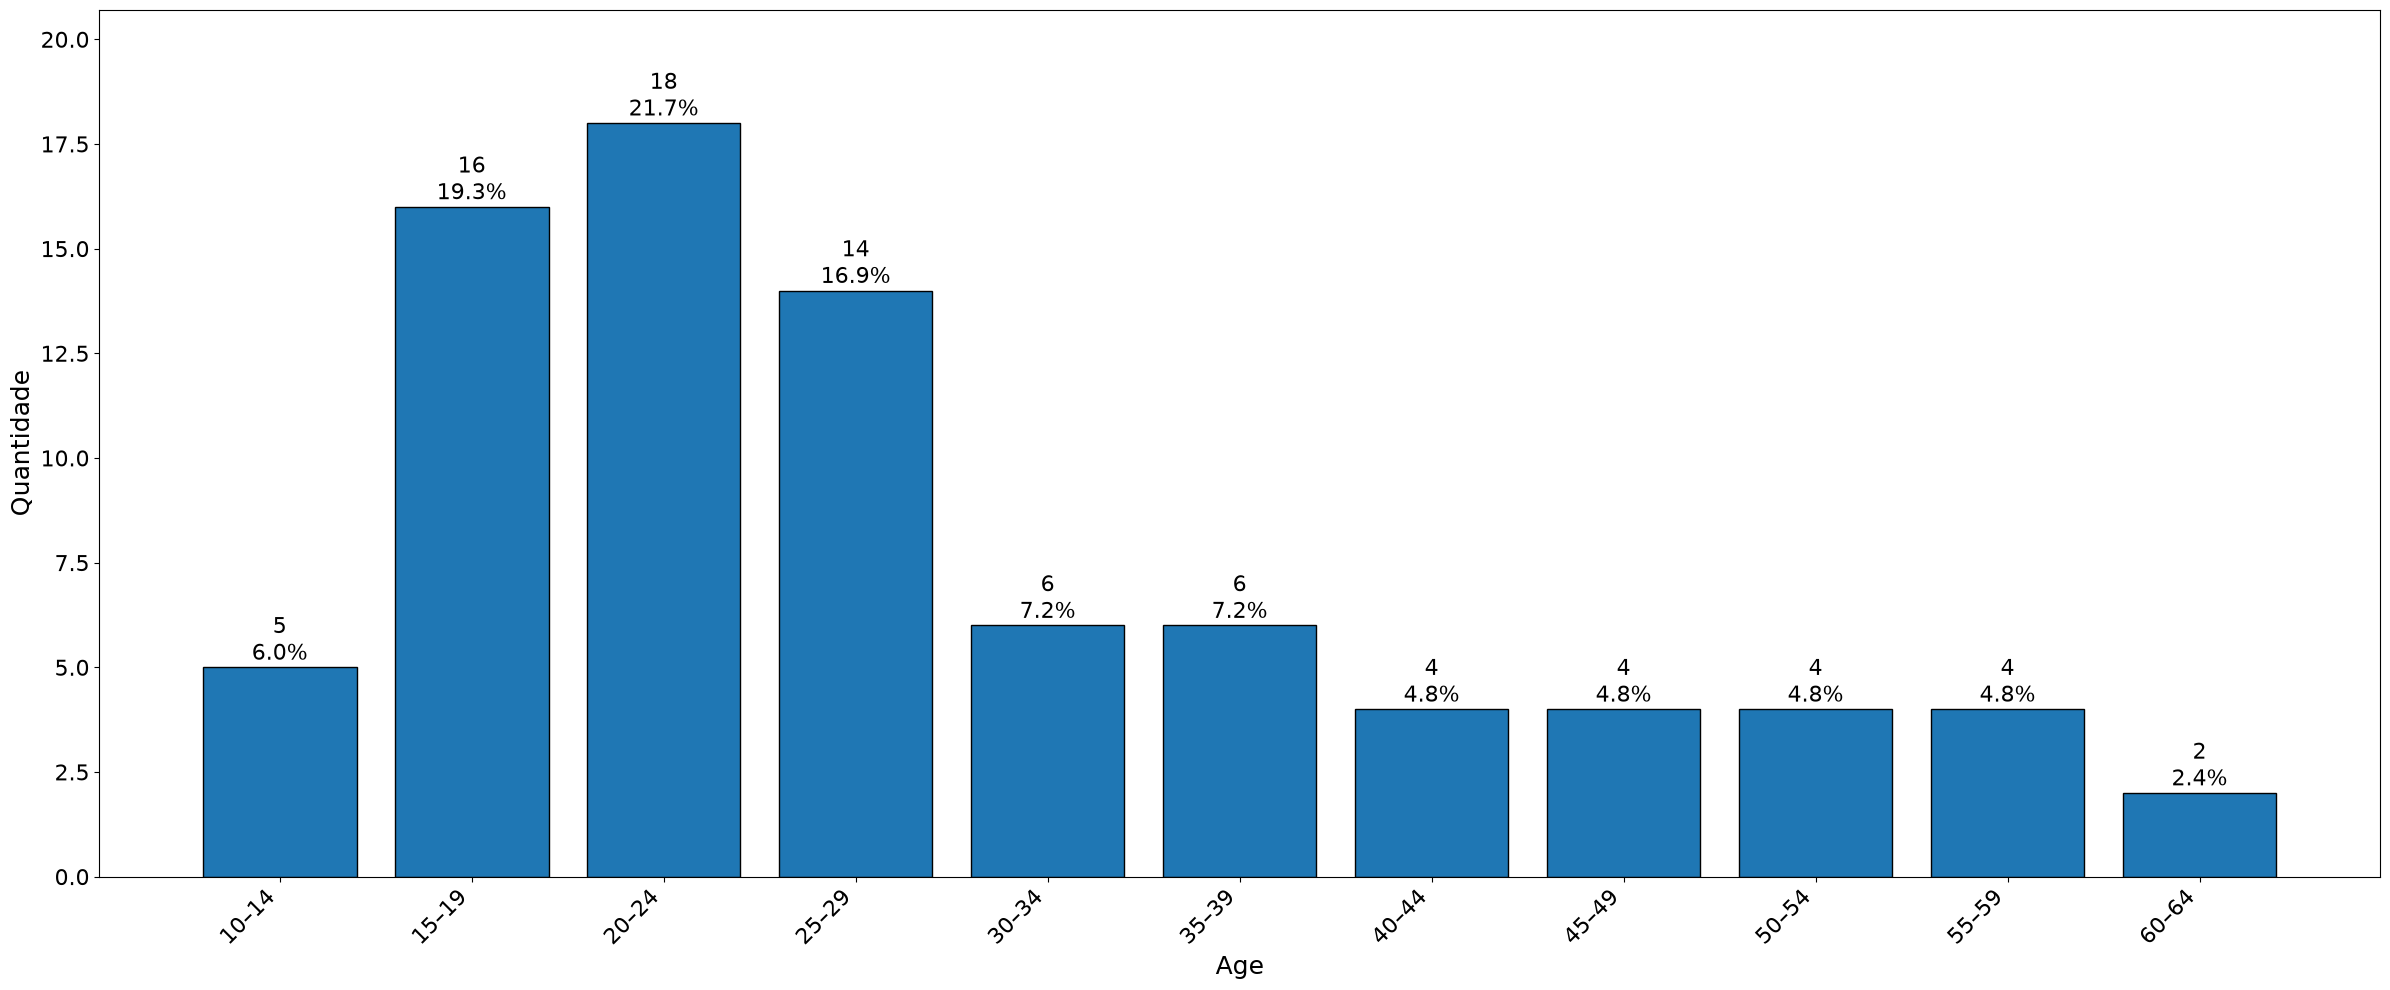

In [6]:
series = dd_df.age

display_column_description(
    series=series,
    type_name="Inteiro",
    feature_type="numerical",
)
plot_histogram(
    series=series,
    show_value=True,
    percentage_function=lambda value, data: value / len(data),
    bin_width=5,
)
display(HTML("<hr/>"))

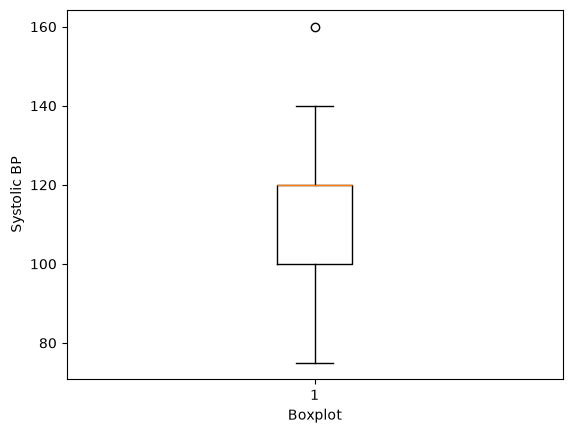

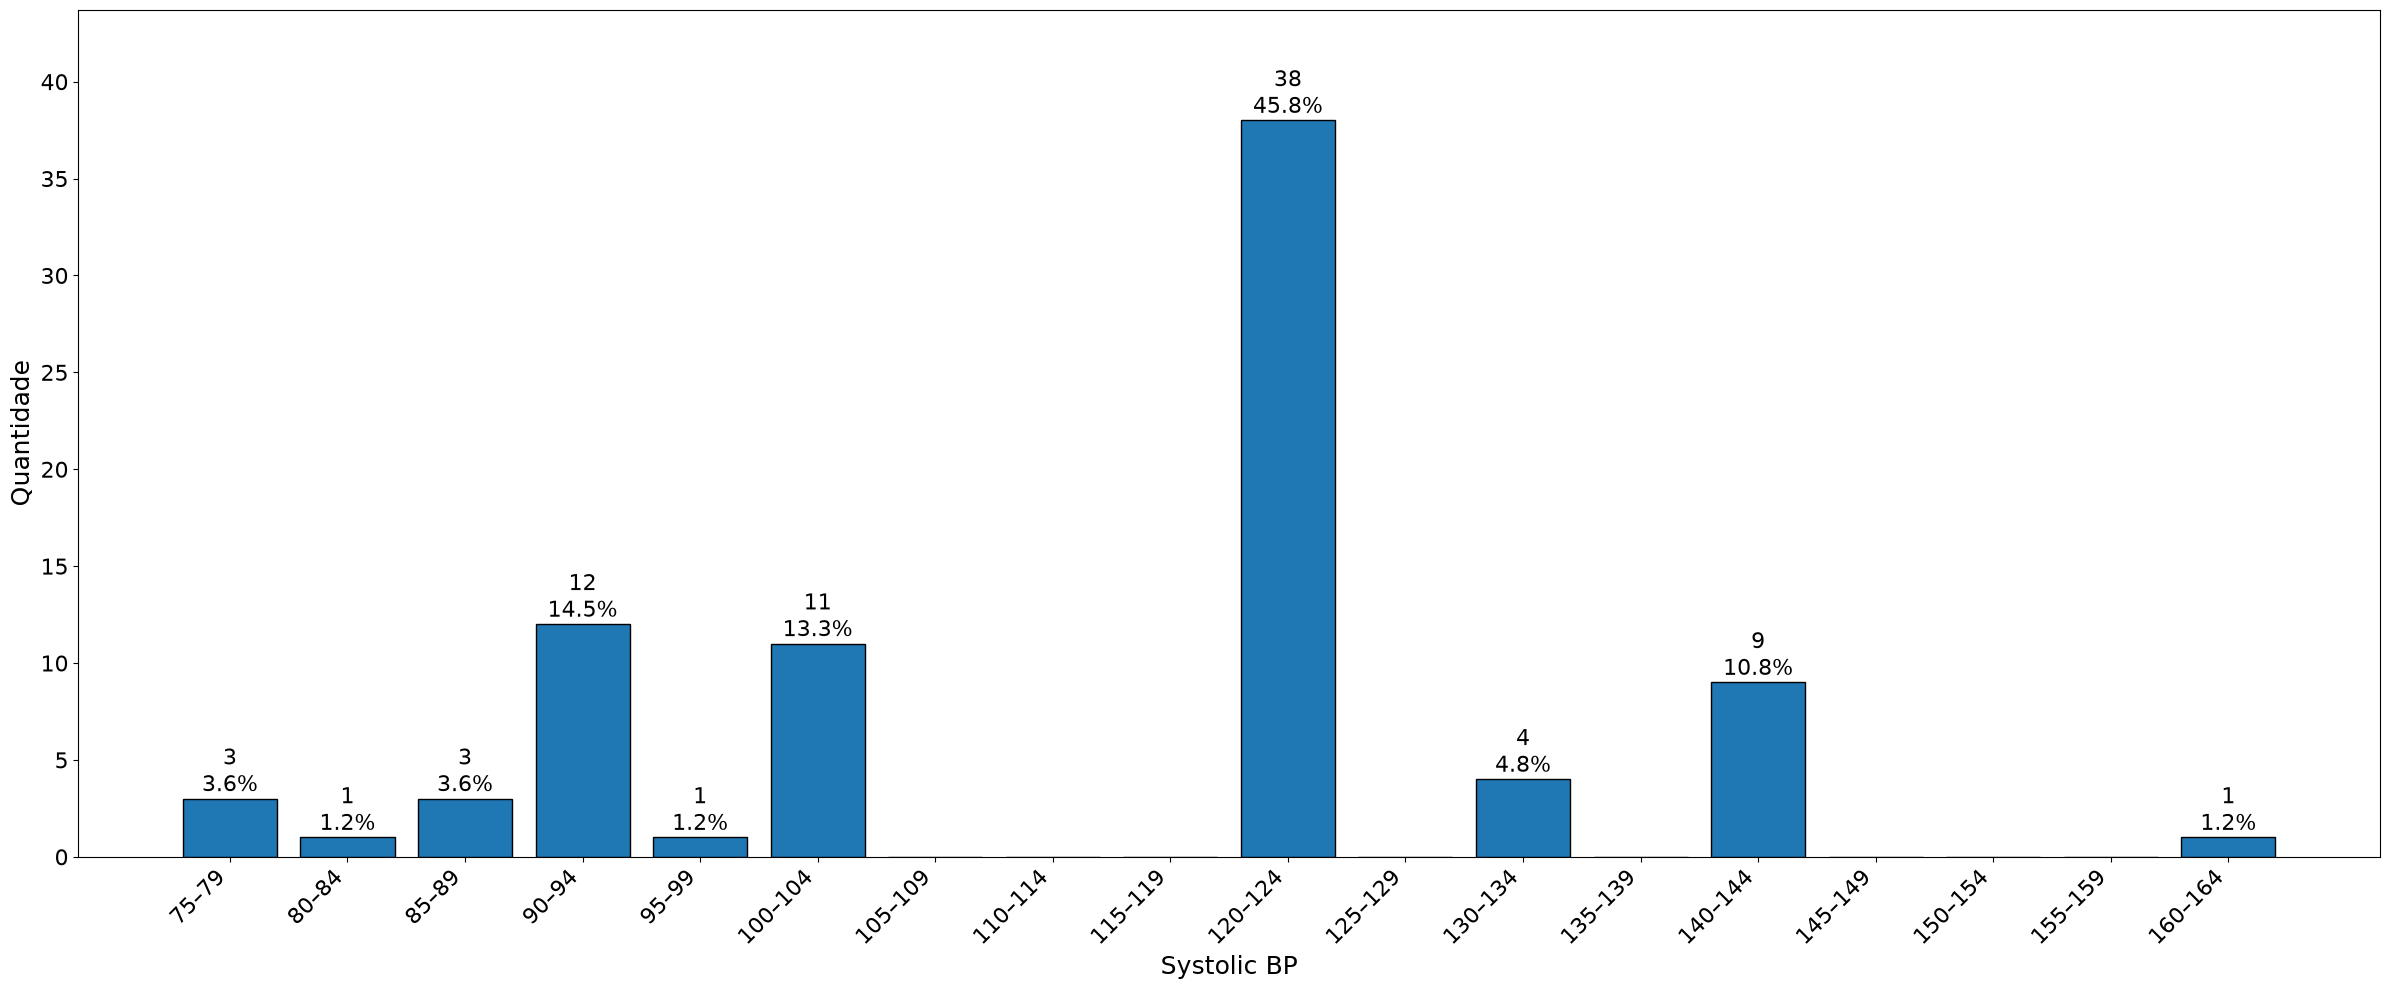

In [7]:
series = dd_df.systolic_bp

display_column_description(
    series=series,
    type_name="Inteiro",
    feature_type="numerical",
)
plot_histogram(
    series=series,
    show_value=True,
    percentage_function=lambda value, data: value / len(data),
    bin_width=5,
)
display(HTML("<hr/>"))

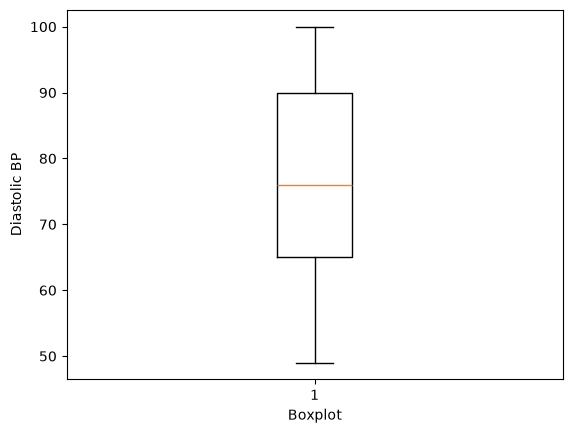

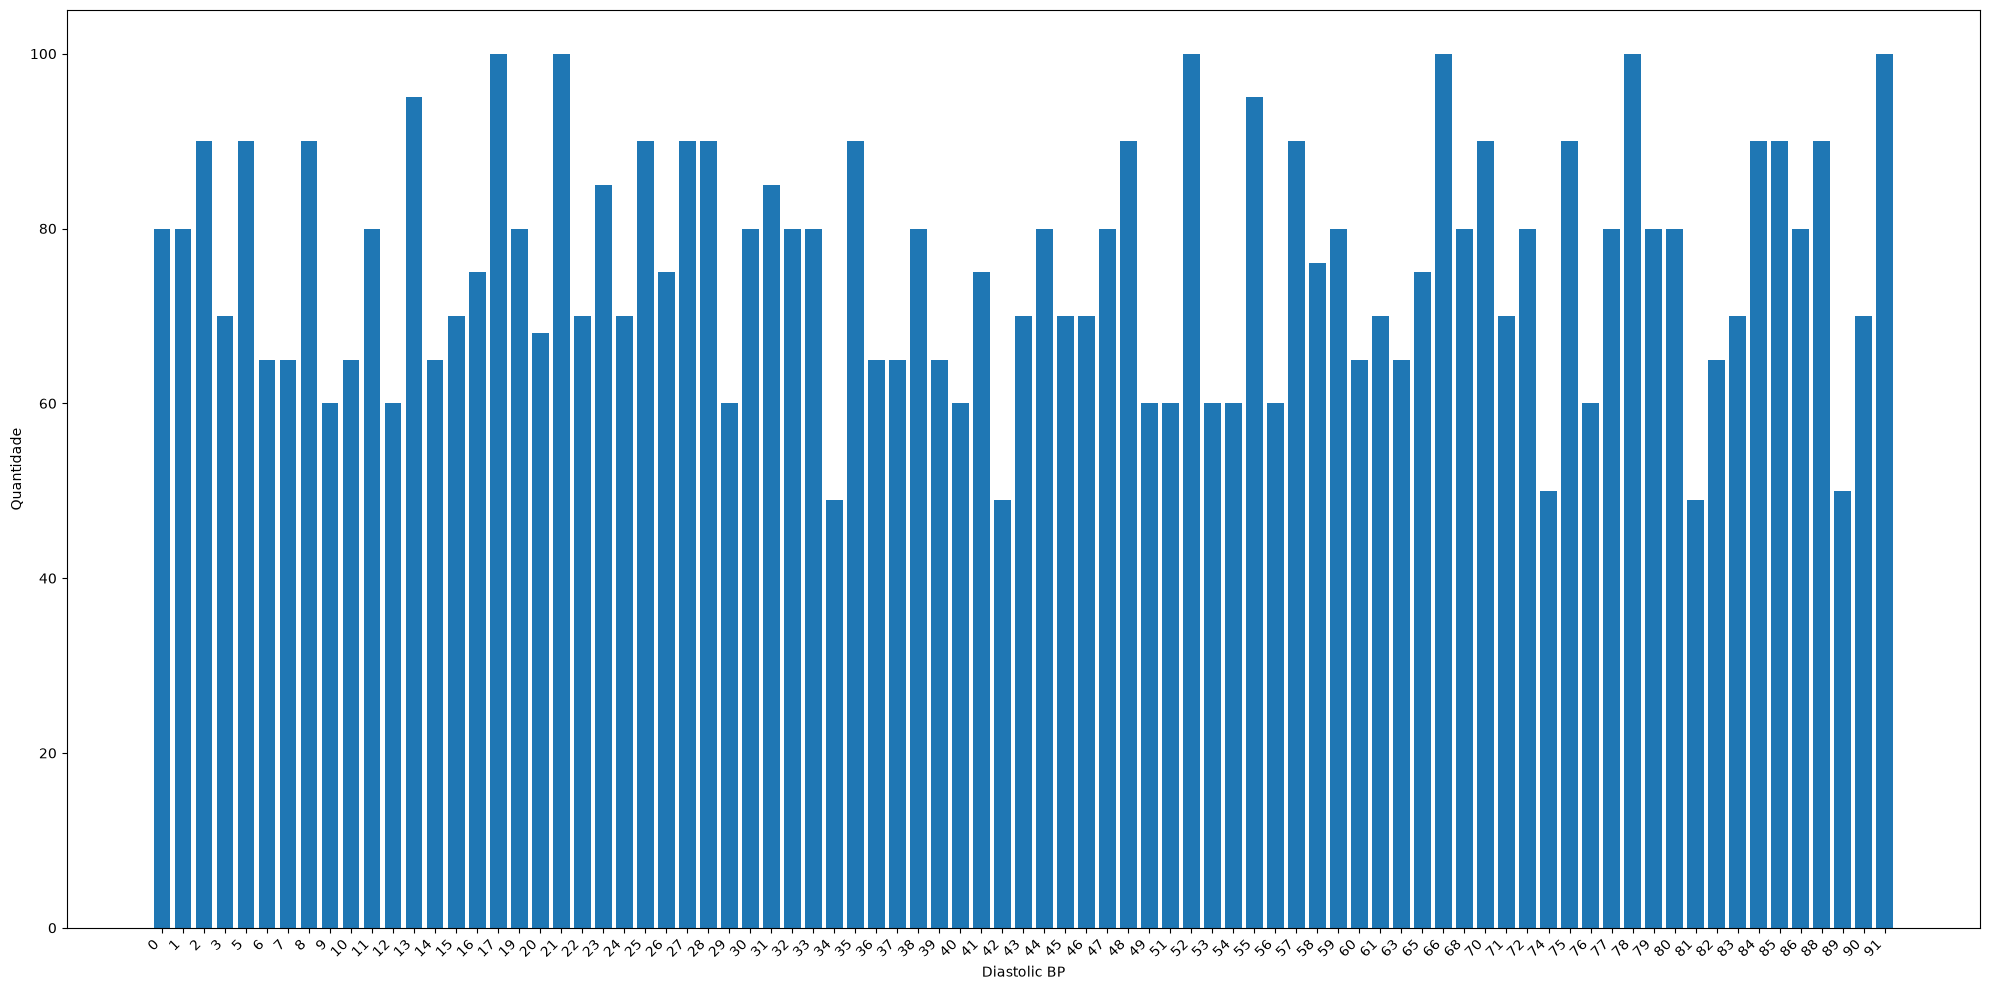

In [8]:
series = dd_df.diastolic_bp

display_column_description(
    series=series,
    type_name="Inteiro",
    feature_type="numerical",
)
plot_bar_graph(series=series)
display(HTML("<hr/>"))

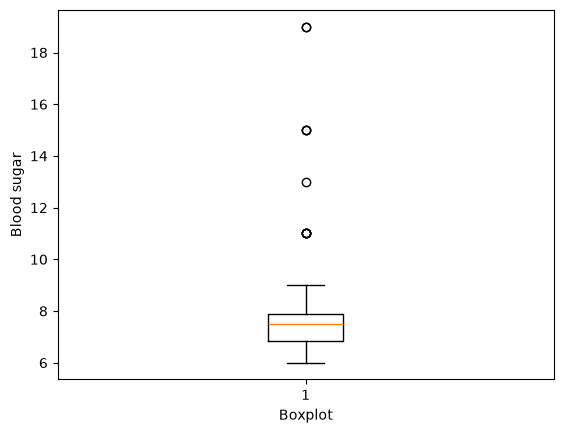

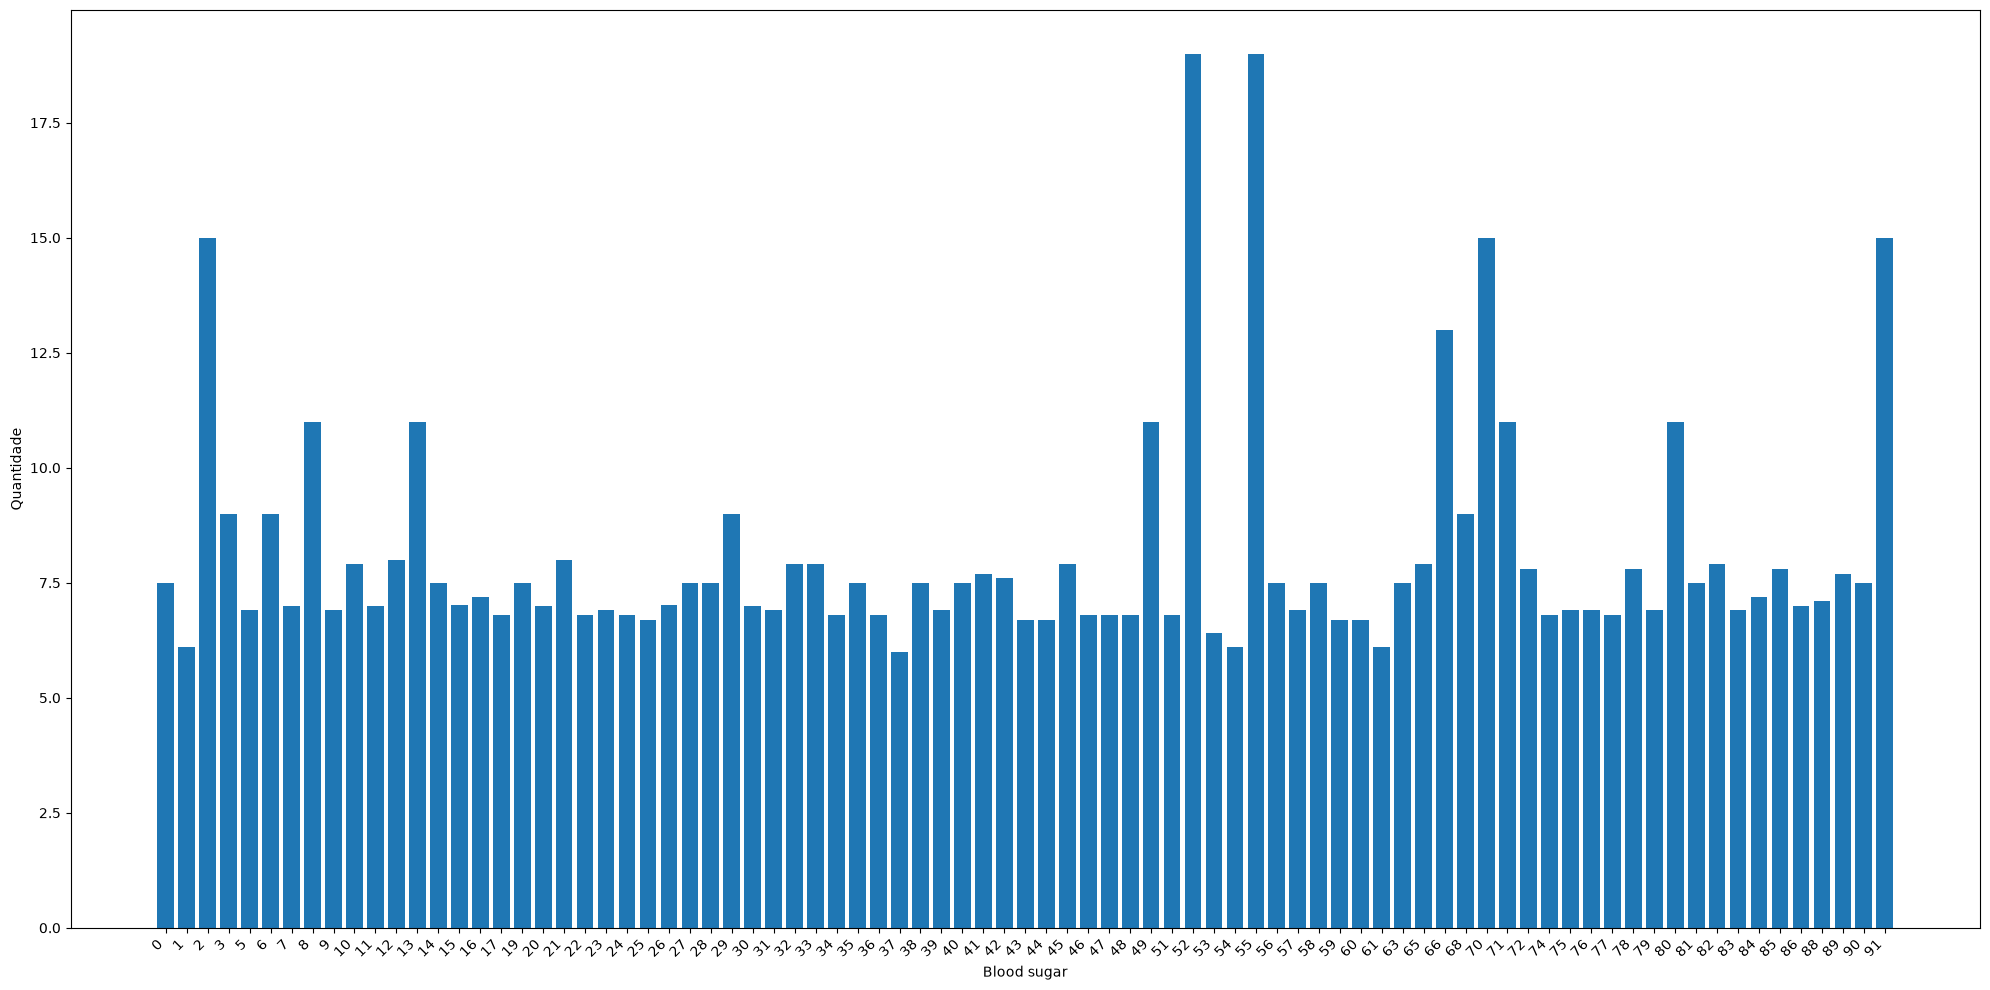

In [9]:
series = dd_df.blood_sugar

display_column_description(
    series=series,
    type_name="Real",
    feature_type="numerical",
)
plot_bar_graph(series=series)
display(HTML("<hr/>"))

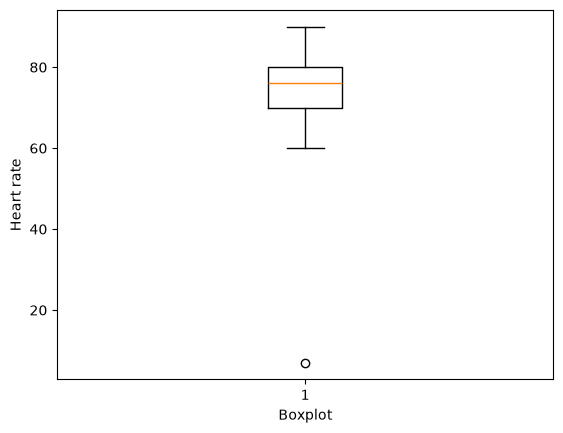

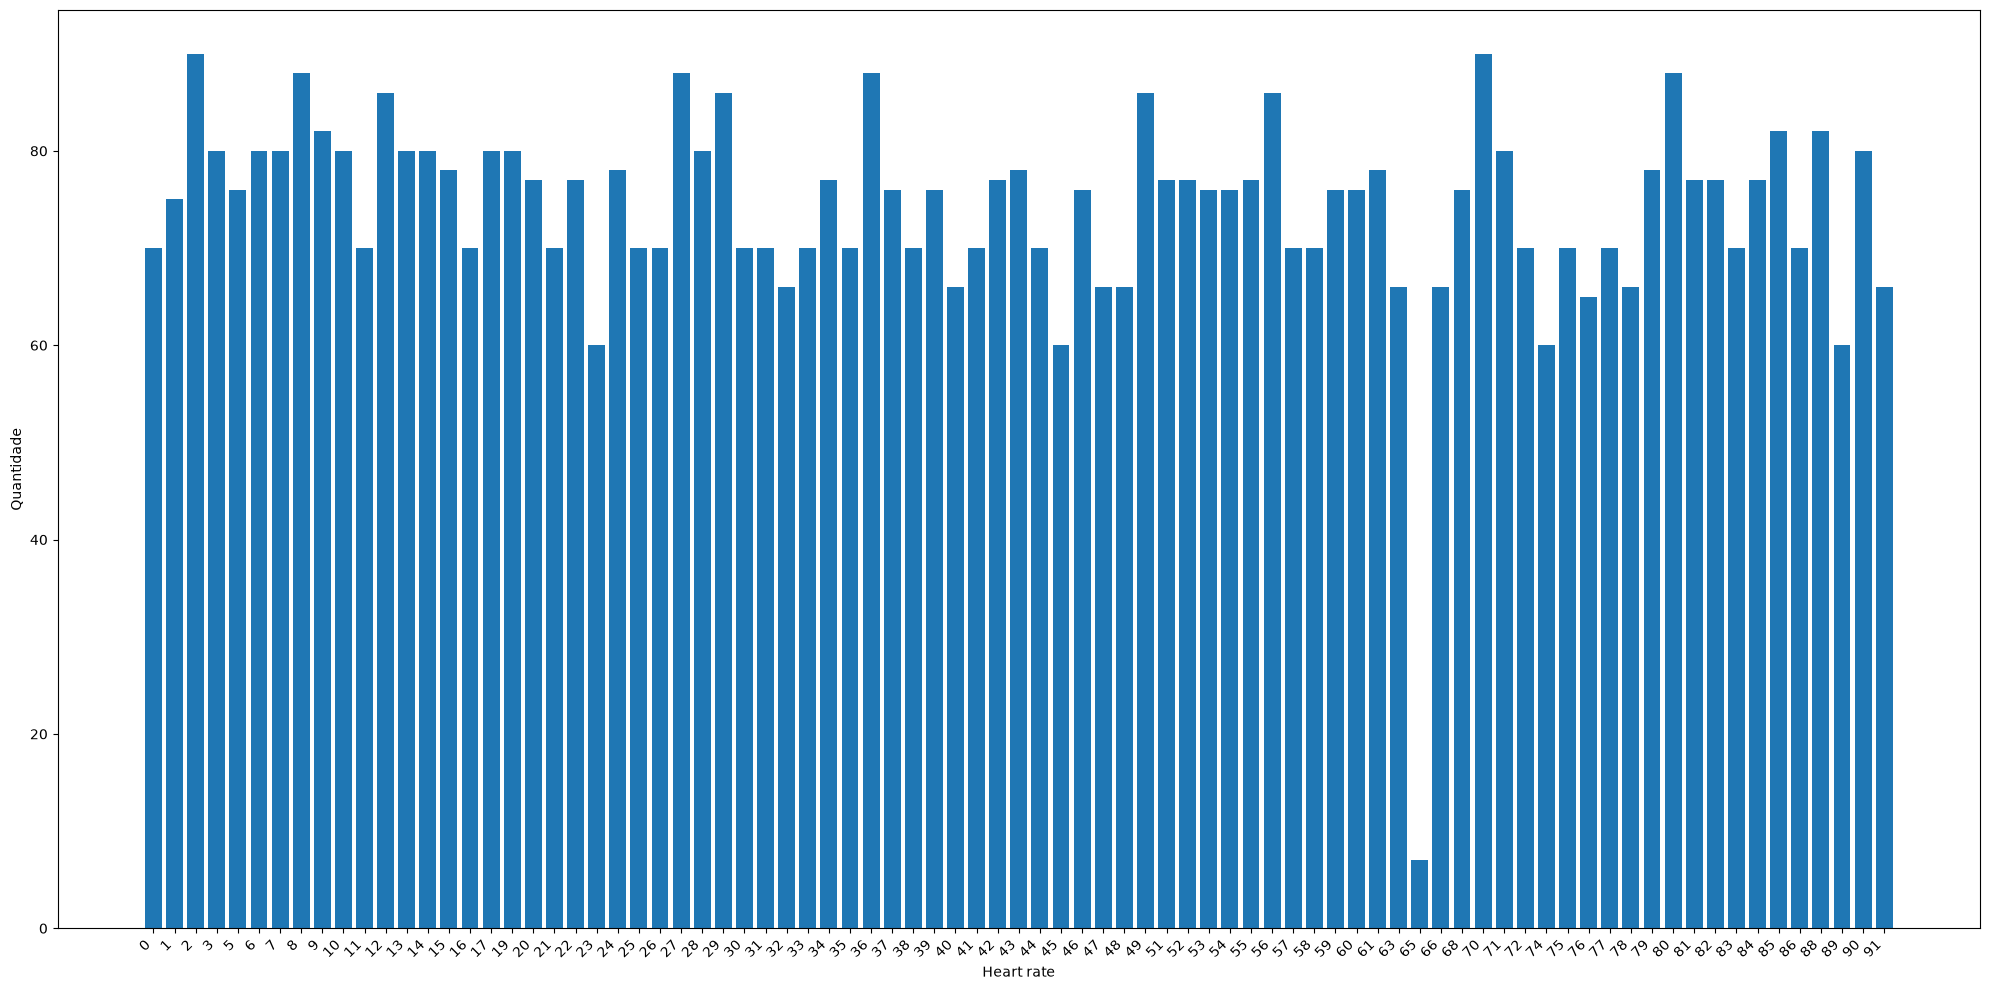

In [10]:
series = dd_df.heart_rate

display_column_description(
    series=series,
    type_name="Inteiro",
    feature_type="numerical",
)
plot_bar_graph(series=series)
display(HTML("<hr/>"))

In [11]:
series = dd_df.risk_level

display_column_description(
    series=series,
    type_name="Categórico",
    feature_type="categorical",
)
plot_bar_graph(series=series)
display(HTML("<hr/>"))

ID,risk_level
Tipo,Categórico
Valores,highlowmid


ValueError: could not convert string to float: 'mid'